# 1. Introduction: Analyzing CNN Embedding Spaces with Varying Dropout

This notebook explores the relationship between the geometric structure of a Convolutional Neural Network's (CNN) embedding space and its classification performance, specifically by varying the dropout rate.

### Objectives:
1.  **Train CNNs:** Train several CNN models with a fixed architecture on CIFAR-10, but with different dropout rates to achieve a range of test accuracies.
2.  **Extract Embeddings:** For each trained model, extract feature vectors (embeddings) from the penultimate layer for all images in the training set.
3.  **Compute Spatial Metrics:** Quantify the quality of the embedding space using metrics that measure class separation (Intra-class distance, Inter-class distance, Silhouette Score, Fisher's Discriminant Ratio).
4.  **Analyze Correlation:** Systematically analyze and visualize the correlation between these spatial metrics and the model's final test-set accuracy.
5.  **Interpret Results:** Discuss how dropout as a regularization technique influences the feature space geometry and its link to generalization.

In [1]:
# Import necessary libraries and set up the environment for reproducibility.

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.decomposition import PCA
import random
import os
from tqdm import tqdm
import json

# --- Configuration ---
# Set a seed for reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Set device to 'cpu' as we are optimizing for a CPU-only environment.
device = torch.device("cpu")
print(f"Using device: {device}")

# --- Paths and Settings ---
RESULTS_FILE = 'experiment_results_dropout.csv'
MODELS_DIR = 'saved_models_dropout'
os.makedirs(MODELS_DIR, exist_ok=True) # Directory to save model checkpoints

# Set to True to re-run all experiments even if results file exists
FORCE_RERUN = False


Using device: cpu


# 3. Data Preparation
 
We will download the CIFAR-10 dataset using `torchvision`. Standard data transformations are applied. Normalization uses the standard mean and standard deviation for the CIFAR-10 dataset.

In [2]:
# Define data transformations
cifar_mean = [0.4914, 0.4822, 0.4465]
cifar_std = [0.2470, 0.2435, 0.2616]

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std),
])

# Download CIFAR-10 dataset
try:
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
except Exception as e:
    print(f"Failed to download CIFAR-10, attempting to load from local. Error: {e}")
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_train)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform_test)


# Create DataLoaders for training, testing, and embedding extraction
trainset_for_embedding = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_test)

train_loader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=0, pin_memory=False)
test_loader = DataLoader(testset, batch_size=256, shuffle=False, num_workers=0, pin_memory=False)
embedding_loader = DataLoader(trainset_for_embedding, batch_size=256, shuffle=False, num_workers=0, pin_memory=False)


# Define class names
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 4. Model Definition
 
We define a VGG-style CNN with a fixed "tiny" architecture. The key change is the addition of a `dropout_rate` parameter. A `nn.Dropout` layer is added right before the final fully-connected layer to regularize the model.
 
The embedding is extracted from the features *before* they pass through the dropout layer, giving us a clean representation of the learned features.

In [3]:
class CNNWithDropout(nn.Module):
    """A CNN with a fixed architecture and configurable dropout."""
    def __init__(self, dropout_rate=0.5, num_classes=10):
        super(CNNWithDropout, self).__init__()
        
        # Fixed "tiny and fast" architecture
        channels_config = [32, 64]
        
        layers = []
        in_channels = 3
        
        # Create convolutional blocks
        for out_channels in channels_config:
            layers.extend([
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),
            ])
            in_channels = out_channels
            
        self.features = nn.Sequential(*layers)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Classifier includes dropout for regularization
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_channels, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        embedding = torch.flatten(x, 1)
        # Pass the embedding through the classifier (which includes dropout)
        logits = self.classifier(embedding)
        # We return the embedding from *before* dropout for analysis
        return logits, embedding

# Test the model with a dummy input
model = CNNWithDropout(dropout_rate=0.5).to(device)
dummy_input = torch.randn(2, 3, 32, 32).to(device)
logits, embedding = model(dummy_input)
print(f"Model created with fixed channels and dropout.")
print(f"Model output shape (logits): {logits.shape}")
print(f"Model output shape (embedding): {embedding.shape}")

Model created with fixed channels and dropout.
Model output shape (logits): torch.Size([2, 10])
Model output shape (embedding): torch.Size([2, 64])


# 5. Training and Evaluation Loop
 
The training and evaluation functions remain the same, but the main `train_model` function is now simplified to take a configuration that specifies the dropout rate and number of epochs.

In [4]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Trains the model for one epoch."""
    model.train()
    running_loss = 0.0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits, _ = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    return running_loss / len(dataloader.dataset)

def evaluate(model, dataloader, device):
    """Evaluates the model's accuracy on the given dataset."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            logits, _ = model(inputs)
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def train_model(config):
    """Main training loop."""
    print(f"\n--- Training with config: {config['name']} (Dropout: {config['dropout_rate']}) ---")

    # Build model based on dropout config
    model = CNNWithDropout(dropout_rate=config['dropout_rate']).to(device)
    
    # Apply JIT compilation to the model for faster execution
    model = torch.jit.script(model)

    # Use a fixed fast learning rate
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0

    for epoch in range(config['epochs']):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        test_acc = evaluate(model, test_loader, device)
        print(f"Epoch {epoch+1}/{config['epochs']} | Train Loss: {train_loss:.4f} | Test Acc: {test_acc:.2f}%")
        if test_acc > best_acc:
            best_acc = test_acc

    print(f"Finished Training. Final Test Accuracy: {best_acc:.2f}%")
    return model, best_acc


In [5]:
def extract_embeddings(model, dataloader, device):
    """Extracts embeddings and labels for the given dataset."""
    model.eval()
    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Extracting Embeddings"):
            inputs = inputs.to(device)
            _, embeddings_batch = model(inputs)
            all_embeddings.append(embeddings_batch.cpu().numpy())
            all_labels.append(labels.numpy())

    embeddings_np = np.concatenate(all_embeddings, axis=0)
    labels_np = np.concatenate(all_labels, axis=0)
    return embeddings_np, labels_np


In [6]:
def compute_centroids(embeddings, labels):
    """Computes class centroids."""
    centroids = []
    for i in range(len(classes)):
        centroids.append(embeddings[labels == i].mean(axis=0))
    return np.array(centroids)

def compute_intra_class_distance(embeddings, labels, centroids):
    """Computes average intra-class distance."""
    avg_distances = []
    for i in range(len(classes)):
        class_embeddings = embeddings[labels == i]
        distances = pairwise_distances(class_embeddings, centroids[i].reshape(1, -1))
        avg_distances.append(distances.mean())
    return np.mean(avg_distances)

def compute_inter_class_distance(centroids):
    """Computes average inter-class distance from centroids."""
    distances = pairwise_distances(centroids)
    return distances[np.triu_indices(len(classes), k=1)].mean()

def compute_fisher_discriminant_ratio(embeddings, labels, centroids):
    """Computes the ratio of traces of between-class and within-class scatter."""
    num_classes = len(centroids)
    d = embeddings.shape[1]
    sw = np.zeros((d, d))
    for i in range(num_classes):
        class_embeddings = embeddings[labels == i]
        diff = class_embeddings - centroids[i]
        sw += diff.T @ diff
    overall_mean = embeddings.mean(axis=0)
    sb = np.zeros((d, d))
    for i in range(num_classes):
        n = (labels == i).sum()
        diff = (centroids[i] - overall_mean).reshape(d, 1)
        sb += n * (diff @ diff.T)
    return np.trace(sb) / np.trace(sw)

def compute_all_metrics(embeddings, labels):
    """Computes and returns a dictionary of all spatial metrics."""
    centroids = compute_centroids(embeddings, labels)
    metrics = {}
    metrics['intra_dist'] = compute_intra_class_distance(embeddings, labels, centroids)
    metrics['inter_dist'] = compute_inter_class_distance(centroids)
    metrics['fisher_ratio'] = compute_fisher_discriminant_ratio(embeddings, labels, centroids)
    
    # Use a smaller sample for silhouette score to keep it fast
    sample_size = 5000
    if len(embeddings) > sample_size:
        indices = np.random.choice(len(embeddings), sample_size, replace=False)
        sampled_embeddings, sampled_labels = embeddings[indices], labels[indices]
    else:
        sampled_embeddings, sampled_labels = embeddings, labels
        
    metrics['silhouette'] = silhouette_score(sampled_embeddings, sampled_labels)
    return metrics


# 8. Experimental Protocol
 
Our new protocol focuses on the `dropout_rate`. We train models with different dropout values and slightly varying epochs to generate a spread in final test accuracies. This allows us to isolate the effect of dropout on the embedding space geometry.
 
The results are saved to `experiment_results_dropout.csv`.

In [7]:
def save_model(model, path):
    """Saves the model's state dictionary."""
    print(f"Saving model to {path}...")
    torch.save(model.state_dict(), path)

def load_model(dropout_rate, path, device):
    """Loads a model's state dictionary into a new model instance."""
    if os.path.exists(path):
        print(f"Loading model from {path} with dropout: {dropout_rate}...")
        # Build the model with the correct dropout rate first
        model = CNNWithDropout(dropout_rate=dropout_rate).to(device)
        model.load_state_dict(torch.load(path, map_location=device))
        model = torch.jit.script(model) # Re-apply JIT compilation
        return model
    else:
        print(f"Model path {path} does not exist.")
        return None

# --- Experiment Configurations ---
# We now vary the dropout rate and epochs, keeping the architecture and LR fixed.
experiment_configs = [
    # Baseline with no dropout
    {'name': 'Dropout_0.0_Fast', 'dropout_rate': 0.0, 'epochs': 5},
    {'name': 'Dropout_0.0_Slow', 'dropout_rate': 0.0, 'epochs': 8},

    # Low dropout
    {'name': 'Dropout_0.1_Fast', 'dropout_rate': 0.1, 'epochs': 6},
    {'name': 'Dropout_0.1_Slow', 'dropout_rate': 0.1, 'epochs': 9},

    # Medium dropout
    {'name': 'Dropout_0.25_Fast', 'dropout_rate': 0.25, 'epochs': 8},
    {'name': 'Dropout_0.25_Slow', 'dropout_rate': 0.25, 'epochs': 12},
    
    # High dropout
    {'name': 'Dropout_0.5_Fast', 'dropout_rate': 0.5, 'epochs': 10},
    {'name': 'Dropout_0.5_Slow', 'dropout_rate': 0.5, 'epochs': 15},
]

results = []

if os.path.exists(RESULTS_FILE) and not FORCE_RERUN:
    print(f"Loading existing results from {RESULTS_FILE}...")
    results_df = pd.read_csv(RESULTS_FILE)
else:
    for config in experiment_configs:
        model, test_acc = train_model(config)
        
        # Use config name for unique model path
        model_filename = f"model_{config['name']}.pth"
        model_path = os.path.join(MODELS_DIR, model_filename)
        save_model(model, model_path)
        
        embeddings_train, labels_train = extract_embeddings(model, embedding_loader, device)
        spatial_metrics = compute_all_metrics(embeddings_train, labels_train)
        
        run_result = {
            'name': config['name'],
            'dropout_rate': config['dropout_rate'],
            'epochs': config['epochs'],
            'test_accuracy': test_acc,
            'model_path': model_path,
            **spatial_metrics
        }
        results.append(run_result)
        
        print("Metrics for this run:", {k: f"{v:.4f}" for k, v in spatial_metrics.items()})

    results_df = pd.DataFrame(results)
    results_df.to_csv(RESULTS_FILE, index=False)

print("\n--- Experimental Results ---")
print(results_df.round(4))


--- Training with config: Dropout_0.0_Fast (Dropout: 0.0) ---
Epoch 1/5 | Train Loss: 1.6226 | Test Acc: 46.60%
Epoch 2/5 | Train Loss: 1.2845 | Test Acc: 43.65%
Epoch 3/5 | Train Loss: 1.1371 | Test Acc: 48.12%
Epoch 4/5 | Train Loss: 1.0485 | Test Acc: 53.52%
Epoch 5/5 | Train Loss: 0.9796 | Test Acc: 60.07%
Finished Training. Final Test Accuracy: 60.07%
Saving model to saved_models_dropout/model_Dropout_0.0_Fast.pth...


Extracting Embeddings: 100%|██████████| 196/196 [00:42<00:00,  4.65it/s]


Metrics for this run: {'intra_dist': '2.6843', 'inter_dist': '3.5957', 'fisher_ratio': '0.8200', 'silhouette': '0.0334'}

--- Training with config: Dropout_0.0_Slow (Dropout: 0.0) ---
Epoch 1/8 | Train Loss: 1.6017 | Test Acc: 48.57%
Epoch 2/8 | Train Loss: 1.2694 | Test Acc: 43.76%
Epoch 3/8 | Train Loss: 1.1360 | Test Acc: 46.50%
Epoch 4/8 | Train Loss: 1.0396 | Test Acc: 60.36%
Epoch 5/8 | Train Loss: 0.9756 | Test Acc: 61.10%
Epoch 6/8 | Train Loss: 0.9233 | Test Acc: 59.21%
Epoch 7/8 | Train Loss: 0.8795 | Test Acc: 61.44%
Epoch 8/8 | Train Loss: 0.8424 | Test Acc: 68.42%
Finished Training. Final Test Accuracy: 68.42%
Saving model to saved_models_dropout/model_Dropout_0.0_Slow.pth...


Extracting Embeddings: 100%|██████████| 196/196 [00:40<00:00,  4.88it/s]


Metrics for this run: {'intra_dist': '2.8496', 'inter_dist': '3.8952', 'fisher_ratio': '0.8536', 'silhouette': '0.0523'}

--- Training with config: Dropout_0.1_Fast (Dropout: 0.1) ---
Epoch 1/6 | Train Loss: 1.6528 | Test Acc: 46.06%
Epoch 2/6 | Train Loss: 1.3481 | Test Acc: 55.69%
Epoch 3/6 | Train Loss: 1.2274 | Test Acc: 55.44%
Epoch 4/6 | Train Loss: 1.1390 | Test Acc: 54.06%
Epoch 5/6 | Train Loss: 1.0744 | Test Acc: 59.17%
Epoch 6/6 | Train Loss: 1.0220 | Test Acc: 57.41%
Finished Training. Final Test Accuracy: 59.17%
Saving model to saved_models_dropout/model_Dropout_0.1_Fast.pth...


...

Metrics for this run: {'intra_dist': '2.4172', 'inter_dist': '3.5003', 'fisher_ratio': '0.9348', 'silhouette': '0.0584'}

--- Training with config: Dropout_0.5_Fast (Dropout: 0.5) ---
Epoch 1/10 | Train Loss: 1.8035 | Test Acc: 37.09%
Epoch 2/10 | Train Loss: 1.5631 | Test Acc: 47.28%
Epoch 3/10 | Train Loss: 1.4585 | Test Acc: 49.41%
Epoch 4/10 | Train Loss: 1.3789 | Test Acc: 50.90%
Epoch 5/10 | Train Loss: 1.3252 | Test Acc: 41.26%
Epoch 6/10 | Train Loss: 1.2688 | Test Acc: 59.13%
Epoch 7/10 | Train Loss: 1.2283 | Test Acc: 52.56%
Epoch 8/10 | Train Loss: 1.1891 | Test Acc: 63.19%
Epoch 9/10 | Train Loss: 1.1554 | Test Acc: 53.62%
Epoch 10/10 | Train Loss: 1.1286 | Test Acc: 60.01%
Finished Training. Final Test Accuracy: 63.19%
Saving model to saved_models_dropout/model_Dropout_0.5_Fast.pth...


Extracting Embeddings: 100%|██████████| 196/196 [00:39<00:00,  4.91it/s]


Metrics for this run: {'intra_dist': '2.2057', 'inter_dist': '3.3311', 'fisher_ratio': '1.0226', 'silhouette': '0.0393'}

--- Training with config: Dropout_0.5_Slow (Dropout: 0.5) ---
Epoch 1/15 | Train Loss: 1.7954 | Test Acc: 44.10%
Epoch 2/15 | Train Loss: 1.5389 | Test Acc: 43.81%
Epoch 3/15 | Train Loss: 1.4459 | Test Acc: 50.94%
Epoch 4/15 | Train Loss: 1.3679 | Test Acc: 55.93%
Epoch 5/15 | Train Loss: 1.3041 | Test Acc: 52.53%
Epoch 6/15 | Train Loss: 1.2585 | Test Acc: 51.03%
Epoch 7/15 | Train Loss: 1.2111 | Test Acc: 57.11%
Epoch 8/15 | Train Loss: 1.1715 | Test Acc: 62.98%
Epoch 9/15 | Train Loss: 1.1378 | Test Acc: 57.69%
Epoch 10/15 | Train Loss: 1.1067 | Test Acc: 54.84%
Epoch 11/15 | Train Loss: 1.0858 | Test Acc: 63.70%
Epoch 12/15 | Train Loss: 1.0669 | Test Acc: 58.94%
Epoch 13/15 | Train Loss: 1.0411 | Test Acc: 66.51%
Epoch 14/15 | Train Loss: 1.0247 | Test Acc: 65.61%
Epoch 15/15 | Train Loss: 1.0134 | Test Acc: 66.17%
Finished Training. Final Test Accuracy: 66.51

Extracting Embeddings: 100%|██████████| 196/196 [00:39<00:00,  4.95it/s]


Metrics for this run: {'intra_dist': '2.1588', 'inter_dist': '3.4752', 'fisher_ratio': '1.2013', 'silhouette': '0.0503'}

--- Experimental Results ---
                name  dropout_rate  epochs  test_accuracy  \
0   Dropout_0.0_Fast          0.00       5          60.07   
1   Dropout_0.0_Slow          0.00       8          68.42   
2   Dropout_0.1_Fast          0.10       6          59.17   
3   Dropout_0.1_Slow          0.10       9          66.40   
4  Dropout_0.25_Fast          0.25       8          65.88   
5  Dropout_0.25_Slow          0.25      12          68.81   
6   Dropout_0.5_Fast          0.50      10          63.19   
7   Dropout_0.5_Slow          0.50      15          66.51   

                                         model_path  intra_dist  inter_dist  \
0   saved_models_dropout/model_Dropout_0.0_Fast.pth      2.6843      3.5957   
1   saved_models_dropout/model_Dropout_0.0_Slow.pth      2.8496      3.8952   
2   saved_models_dropout/model_Dropout_0.1_Fast.pth      2.671


--- Correlation with Test Accuracy ---
intra_dist     -0.091563
inter_dist      0.290494
fisher_ratio    0.408294
silhouette      0.924874
Name: test_accuracy, dtype: float64


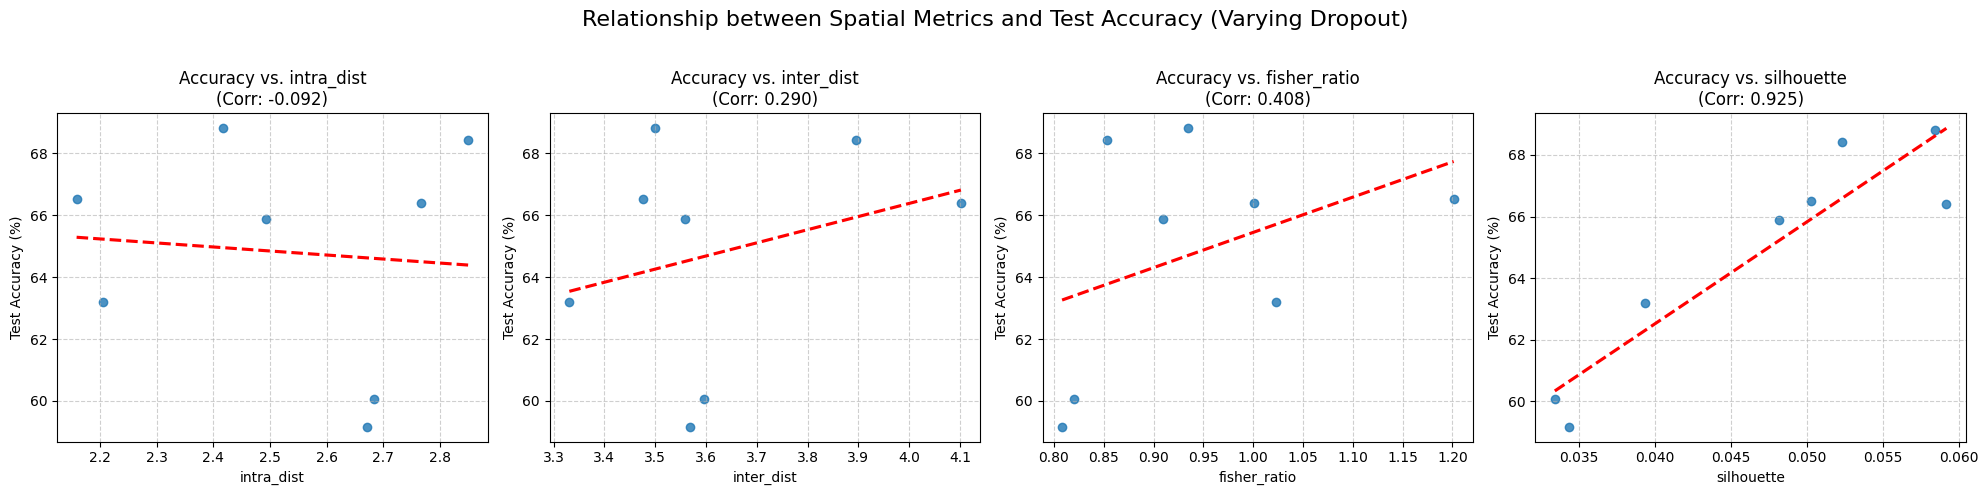

In [8]:
if not results_df.empty:
    metrics_to_plot = ['intra_dist', 'inter_dist', 'fisher_ratio', 'silhouette']
    
    correlations = results_df.corr(numeric_only=True)['test_accuracy'].loc[metrics_to_plot]
    print("\n--- Correlation with Test Accuracy ---")
    print(correlations)
    
    num_metrics = len(metrics_to_plot)
    fig, axes = plt.subplots(1, num_metrics, figsize=(20, 5))
    fig.suptitle('Relationship between Spatial Metrics and Test Accuracy (Varying Dropout)', fontsize=16)
    
    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i]
        sns.regplot(x=metric, y='test_accuracy', data=results_df, ax=ax, ci=None,
                    line_kws={'color': 'red', 'linestyle': '--'})
        ax.set_title(f'Accuracy vs. {metric}\n(Corr: {correlations[metric]:.3f})')
        ax.set_xlabel(metric)
        ax.set_ylabel('Test Accuracy (%)')
        ax.grid(True, linestyle='--', alpha=0.6)
        
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()
else:
    print("Results DataFrame is empty. Run experiments to generate data.")


Visualizing embeddings for the best model: Dropout_0.25_Slow (Accuracy: 68.81%)
Loading model from saved_models_dropout/model_Dropout_0.25_Slow.pth with dropout: 0.25...


Extracting Embeddings: 100%|██████████| 196/196 [00:39<00:00,  4.93it/s]



Performing PCA for 2D visualization...


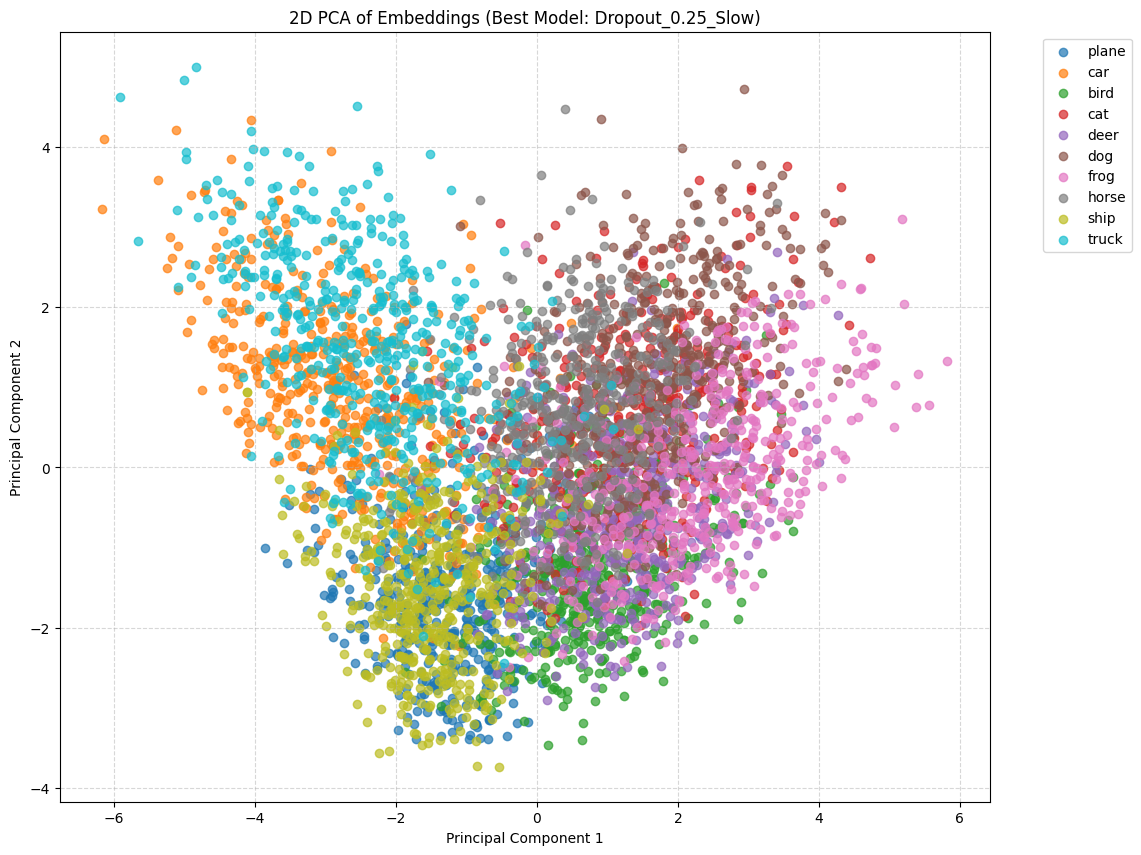

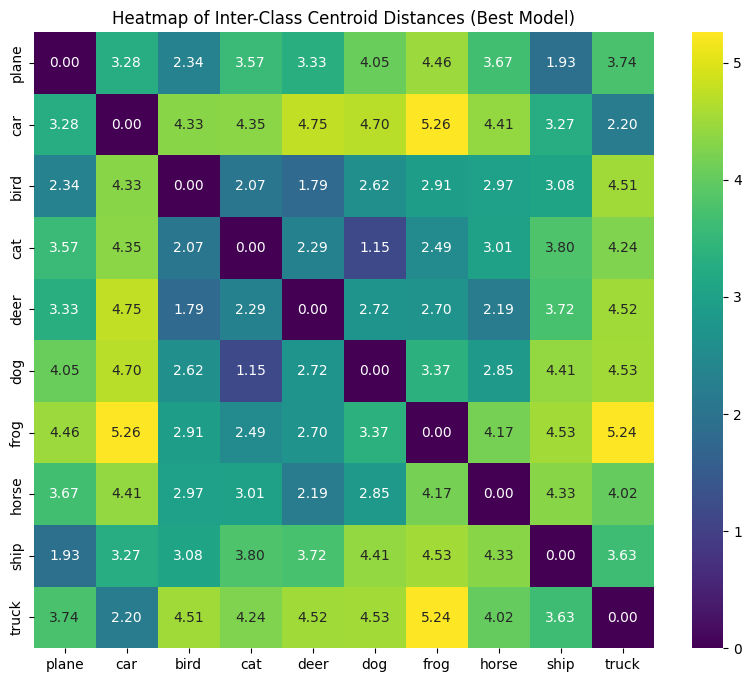

In [9]:
if not results_df.empty:
    best_run = results_df.loc[results_df['test_accuracy'].idxmax()]
    print(f"Visualizing embeddings for the best model: {best_run['name']} (Accuracy: {best_run['test_accuracy']:.2f}%)")

    best_model_path = best_run['model_path']
    best_model_dropout = best_run['dropout_rate']
    
    # Load the best model with its specific dropout rate
    best_model = load_model(best_model_dropout, best_model_path, device)
    
    if best_model:
        embeddings, labels = extract_embeddings(best_model, embedding_loader, device)

        # 1. Visualize with PCA
        print("\nPerforming PCA for 2D visualization...")
        pca = PCA(n_components=2)
        # Use a smaller subset for faster PCA and clearer plotting
        subset_indices = np.random.choice(len(embeddings), 5000, replace=False)
        embeddings_subset = embeddings[subset_indices]
        labels_subset = labels[subset_indices]
        
        embeddings_2d = pca.fit_transform(embeddings_subset)

        plt.figure(figsize=(12, 10))
        for i, class_name in enumerate(classes):
            class_indices = (labels_subset == i)
            plt.scatter(embeddings_2d[class_indices, 0], embeddings_2d[class_indices, 1], label=class_name, alpha=0.7)
        
        plt.title(f'2D PCA of Embeddings (Best Model: {best_run["name"]})')
        plt.xlabel('Principal Component 1')
        plt.ylabel('Principal Component 2')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()

        # 2. Visualize Centroid Distances
        centroids = compute_centroids(embeddings, labels)
        centroid_distances = pairwise_distances(centroids)

        plt.figure(figsize=(10, 8))
        sns.heatmap(centroid_distances, annot=True, fmt=".2f", cmap="viridis",
                    xticklabels=classes, yticklabels=classes)
        plt.title('Heatmap of Inter-Class Centroid Distances (Best Model)')
        plt.show()

else:
    print("Cannot perform visualization because results are empty.")